In [ ]:
# crowdflower/twitter-airline-sentiment

import kagglehub, shutil, os

url = input()  # e.g. PromptCloudHQ/flipkart-products

path = kagglehub.dataset_download(url)

for f in os.listdir(path):
    shutil.copy(os.path.join(path, f), '.')

print("Done")

100%|██████████| 225k/225k [00:01<00:00, 216kB/s]

Extracting files...
Done


# Social Media Analytics – Practical

## Dataset Overview

This experiment uses two datasets:

1. **Twitter Dataset (General Analysis)**
   - Contains tweets related to airline services
   - Used for sentiment analysis, text analytics, and visualization
   - Represents general social media behavior

2. **Flipkart Product Dataset (Regional Analysis)**
   - Contains product reviews and details from Flipkart
   - Used to analyze customer sentiment across different regions/localities
   - Represents product-based regional analytics

## Objective

- To perform data extraction, cleaning, and preprocessing
- To analyze sentiment of user-generated content
- To visualize patterns and trends in social media data
- To compare general vs regional insights

## Tools & Technologies Used

- Python
- Pandas (data handling)
- Matplotlib / Seaborn (visualization)
- WordCloud (text visualization)

## Key Concepts Used

- Text Cleaning
- Sentiment Analysis
- Data Visualization
- Social Media Analytics

In [89]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

In [90]:
# Load datasets
tweets = pd.read_csv("C:/Projects/SEM 8 VIVA/SMA/Tweets.csv")

In [91]:
# Previe
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

## Exp 1: Data Extraction using Python

Data extraction refers to the process of retrieving relevant data from a source such as CSV files, databases, or web platforms. In social media analytics, extraction helps in selecting only useful information required for analysis. It is the first step in the data processing pipeline.

### Features
- Efficient handling of structured data
- Supports large datasets
- Easy filtering and selection of required data
- Integration with analysis tools

### Steps
1. Import required libraries (Pandas)
2. Load dataset using read_csv()
3. Inspect data using head() and info()
4. Select relevant columns
5. Filter required data

The extracted data was successfully filtered and structured for further processing and analysis.

In [92]:
# Extract important columns from tweets dataset
tweet_data = tweets[['text', 'airline_sentiment']]

# Display extracted data
print("Tweet Data:")
tweet_data.head()


Tweet Data:


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [93]:
negative_tweets = tweets[tweets['airline_sentiment'] == 'negative']

print("\nNegative Tweets:")
negative_tweets.head()


Negative Tweets:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
15,570282469121007616,negative,0.6842,Late Flight,0.3684,Virgin America,NaN,smartwatermelon,NaN,0,@VirginAmerica SFO-PDX schedule is still MIA.,NaN,2015-02-24 10:01:50 -0800,"palo alto, ca",Pacific Time (US & Canada)
17,570276917301137409,negative,1.0000,Bad Flight,1.0000,Virgin America,NaN,heatherovieda,NaN,0,@VirginAmerica I flew from NYC to SFO last we...,NaN,2015-02-24 09:39:46 -0800,this place called NYC,Eastern Time (US & Canada)


In [94]:
print("\nTweet Dataset Info:")
print(tweets.info())


Tweet Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non

In [95]:
print("Tweets Shape:", tweets.shape)

Tweets Shape: (14640, 15)


## EXP 2: Data Extraction using Octoparse

Octoparse is a no-code web scraping tool used to extract structured data from websites. It allows users to collect data without programming by selecting elements visually. It is widely used for extracting data from dynamic and complex web pages.

### Features
- No coding required
- Supports dynamic and JavaScript-based websites
- Automatic data detection
- Export to CSV, Excel

### Steps
1. Open Octoparse and create a new task
2. Enter the target website URL
3. Select required elements on the webpage
4. Configure pagination or scrolling
5. Run extraction process
6. Export data into CSV format

Data was successfully extracted from the website and stored in a structured format for analysis.

## EXP 3: Data Cleaning using Python

Data cleaning is the process of removing noise, inconsistencies, and missing values from a dataset. Social media data is often unstructured and contains unwanted elements such as URLs, mentions, and special characters. Cleaning ensures better data quality for analysis.

### Features
- Improves data accuracy
- Removes noise and unwanted data
- Handles missing values
- Standardizes text data

### Steps
1. Identify missing values using isnull()
2. Remove or handle missing data
3. Remove URLs, mentions, hashtags
4. Remove special characters
5. Convert text to lowercase
6. Remove duplicate entries

The dataset was cleaned successfully and prepared for further analysis.

In [35]:
tweets.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
clean_text                          0
dtype: int64

In [56]:
tweets = tweets.dropna(subset=["tweet_location", "user_timezone"])
tweets.isnull().sum()

tweet_id                           0
airline_sentiment                  0
airline_sentiment_confidence       0
negativereason                  3084
negativereason_confidence       2370
airline                            0
airline_sentiment_gold          7738
name                               0
negativereason_gold             7742
retweet_count                      0
text                               0
tweet_coord                     7077
tweet_created                      0
tweet_location                     0
user_timezone                      0
dtype: int64

In [57]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)     # remove URLs
    text = re.sub(r"@\w+", "", text)        # remove mentions
    text = re.sub(r"#\w+", "", text)        # remove hashtags
    text = re.sub(r"[^A-Za-z\s]", "", text) # remove special chars
    return text.lower()

tweets['clean_text'] = tweets['text'].apply(clean_text)

In [58]:
tweets.shape

(7758, 16)

In [60]:
tweets[['text', 'clean_text']].head()

,text,clean_text
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take anothe...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm ...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men wit...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i didntbut now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early your...


In [61]:
tweets = tweets.drop_duplicates(subset='clean_text')

## EXP 4: Data Cleaning for Regional (Multilingual) Data using Python

### Aim
To clean and preprocess multilingual (regional language) text data using Python.

### Theory
Multilingual data contains text in multiple languages such as Hindi, English, and other regional languages. Such data often includes mixed scripts, noise, and inconsistencies. Cleaning multilingual data requires handling Unicode characters and preserving language-specific text while removing unwanted elements.

### Features
- Supports multiple languages (Hindi, English, etc.)
- Handles Unicode characters
- Removes noise while preserving meaning
- Prepares data for sentiment analysis

### Steps
1. Load multilingual dataset
2. Identify missing values
3. Remove unwanted characters and noise
4. Preserve language-specific characters
5. Normalize and clean text
6. Store cleaned data

The multilingual dataset was successfully cleaned and prepared for further analysis.

In [117]:
from datasets import load_dataset
dataset = load_dataset("dhruv0808/indic_sentiment_analyzer")
df = dataset['train'].to_pandas()

In [118]:
df.head()

,Sentence,Label
0,The crisis management team is still assessing ...,Neutral
1,ಅಗತ್ಯವಿರುವವರಿಗೆ ಪರಿಹಾರ ಸಾಮಗ್ರಿಗಳನ್ನು ವಿತರಿಸಲಾಗ...,Neutral
2,தொலைக்காட்சியில் நீதிமன்ற நாடகங்கள் வழக்கறிஞர்...,Positive
3,இந்த மாதத்திற்கான ஊதியத்தை hr துறை சரியான நேரத...,Neutral
4,টুইটারে গ্রাহক পরিষেবা খুব সহায়ক এবং বন্ধুত্ব...,Positive


In [122]:
df.columns

Index(['Sentence', 'Label'], dtype='object')

In [123]:
df.isnull().sum()

Sentence    26
Label       26
dtype: int64

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_multilingual(text):
    text = str(text)
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)

    text = text.lower()
    
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

df['clean_text'] = df['Sentence'].apply(clean_multilingual)

[nltk_data] Downloading package stopwords to C:\Users\Soham
[nltk_data]     Mandavkar/nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [131]:
df[['Sentence', 'clean_text']]

,Sentence,clean_text
0,The crisis management team is still assessing ...,crisis management team still assessing situati...
1,ಅಗತ್ಯವಿರುವವರಿಗೆ ಪರಿಹಾರ ಸಾಮಗ್ರಿಗಳನ್ನು ವಿತರಿಸಲಾಗ...,ಅಗತಯವರವವರಗ ಪರಹರ ಸಮಗರಗಳನನ ವತರಸಲಗತತದ
2,தொலைக்காட்சியில் நீதிமன்ற நாடகங்கள் வழக்கறிஞர்...,தலககடசயல நதமனற நடகஙகள வழககறஞரகள மறறம வழககறஞரகள...
3,இந்த மாதத்திற்கான ஊதியத்தை hr துறை சரியான நேரத...,இநத மதததறகன ஊதயதத hr தற சரயன நரததல சயலககயத
4,টুইটারে গ্রাহক পরিষেবা খুব সহায়ক এবং বন্ধুত্ব...,টইটর গরহক পরষব খব সহযক এব বনধতবপরণ ছল
...,...,...
131039,None,none
131040,None,none
131041,None,none
131042,None,none


## EXP 5: Identify Traffic Bots on Website

Traffic bots are automated programs that generate fake or abnormal activity on websites. Identifying such bots is important for maintaining accurate analytics and ensuring system security. Bots usually show unusual behavior such as high frequency actions.

### Features
- Detects abnormal user behavior
- Improves data reliability
- Helps in security analysis
- Supports anomaly detection

### Steps
1. Analyze user activity data
2. Count actions per user
3. Define threshold for abnormal behavior
4. Identify high activity users
5. Label such users as bots

Users with abnormal activity patterns were identified as potential bots based on defined conditions.

In [96]:
user_activity = tweets['name'].value_counts()
user_activity


name
JetBlueNews        63
kbosspotter        32
_mhertz            29
otisday            28
throthra           27
                   ..
YupitsTate          1
dhepburn            1
itsropes            1
KristenReenders     1
Ag03Recruiter       1
Name: count, Length: 7701, dtype: int64

In [98]:
# Threshold: users with more than 50 tweets
bot_users = user_activity[user_activity > 25]

print("Potential Bots:")
bot_users

Potential Bots:


name
JetBlueNews    63
kbosspotter    32
_mhertz        29
otisday        28
throthra       27
Name: count, dtype: int64

## EXP 6: Dashboard using Power BI

Power BI is a business intelligence tool used to create interactive dashboards and visual reports from data. It helps in analyzing large datasets and presenting insights in a visual format for better decision-making.

### Features
- Interactive visualizations (charts, graphs, maps)
- Real-time data updates
- Drag-and-drop interface
- Integration with multiple data sources

### Steps
1. Import dataset into Power BI
2. Clean and transform data using Power Query
3. Create visualizations (bar chart, pie chart, etc.)
4. Arrange visuals into dashboard
5. Apply filters and slicers
6. Save and publish dashboard

The dashboard was successfully created to visualize and analyze data effectively.

## EXP 7: Dashboard using Excel

Excel is a widely used tool for data analysis and visualization. It allows users to create dashboards using charts, pivot tables, and slicers. It is simple and effective for small to medium datasets.

### Features
- Easy to use interface
- Pivot tables for data summarization
- Charts and graphs for visualization
- Slicers for interactivity

### Steps
1. Load dataset into Excel
2. Clean and organize data
3. Create pivot tables
4. Generate charts (bar, pie, line)
5. Add slicers for filtering
6. Arrange charts into dashboard layout

The dashboard was created successfully using Excel for basic data analysis and visualization.

## EXP 8: Dashboard using Tableau

Tableau is a powerful data visualization tool used to create interactive and dynamic dashboards. It helps in analyzing complex datasets and presenting insights through advanced visualizations.

### Features
- Drag-and-drop visualization
- Interactive dashboards
- Supports large datasets
- Advanced analytics and filters

### Steps
1. Connect dataset to Tableau
2. Explore and prepare data
3. Create visualizations (charts, maps)
4. Combine visuals into dashboard
5. Add filters and interactivity
6. Publish dashboard

The dashboard was successfully designed to provide meaningful insights through visual representation.

## EXP 9: Data Visualization for Social Media Dataset

### Aim
To visualize social media data using Python.

### Theory
Data visualization is the process of representing data in graphical form such as charts and graphs. It helps in understanding patterns, trends, and relationships in data. In social media analytics, visualization is used to analyze sentiment distribution, user behavior, and trends.

### Features
- Easy understanding of complex data
- Identifies trends and patterns
- Supports decision-making
- Interactive and visual representation

### Steps
1. Load and clean dataset
2. Select relevant columns
3. Create visualizations using libraries
4. Analyze patterns and trends
5. Display graphs

The data was successfully visualized to identify trends and patterns in social media activity.

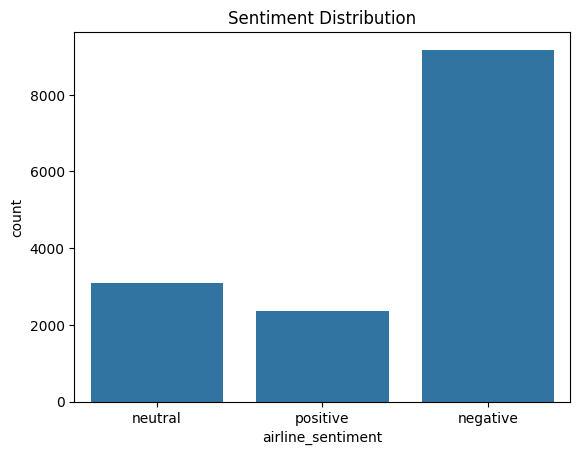

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='airline_sentiment', data=tweets)
plt.title("Sentiment Distribution")
plt.show()

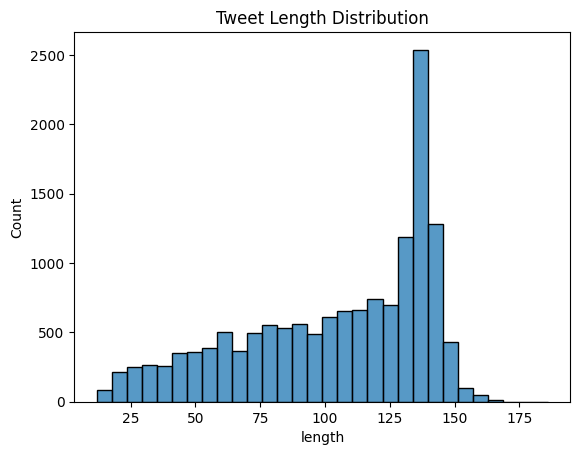

In [100]:
tweets['length'] = tweets['text'].apply(len)

sns.histplot(tweets['length'], bins=30)
plt.title("Tweet Length Distribution")
plt.show()

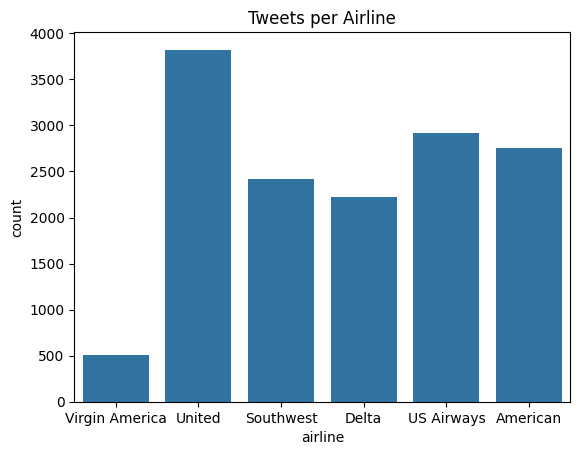

In [ ]:
sns.countplot(x='airline', data=tweets)
plt.title("Tweets per Airline")
plt.xticks(rotation=45)
plt.show()

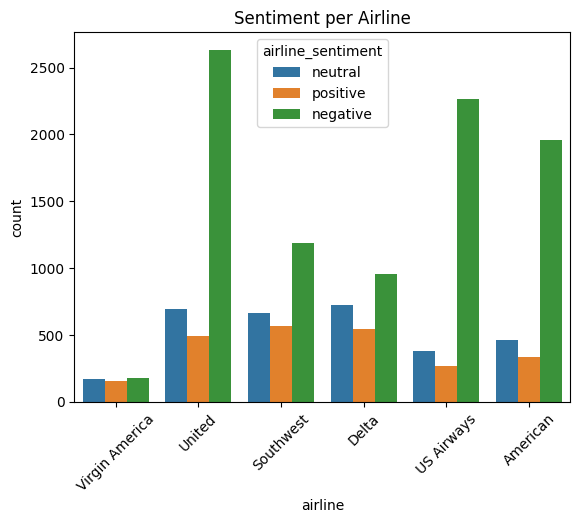

In [102]:
sns.countplot(x='airline', hue='airline_sentiment', data=tweets)
plt.title("Sentiment per Airline")
plt.xticks(rotation=45)
plt.show()

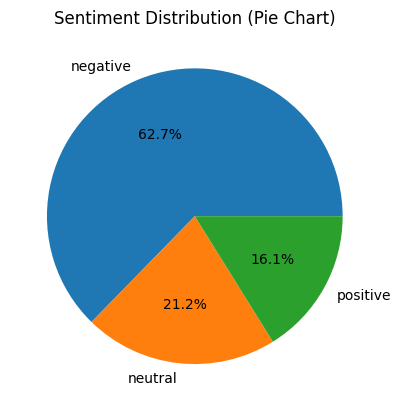

In [103]:
sentiment_counts = tweets['airline_sentiment'].value_counts()

plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Sentiment Distribution (Pie Chart)")
plt.show()

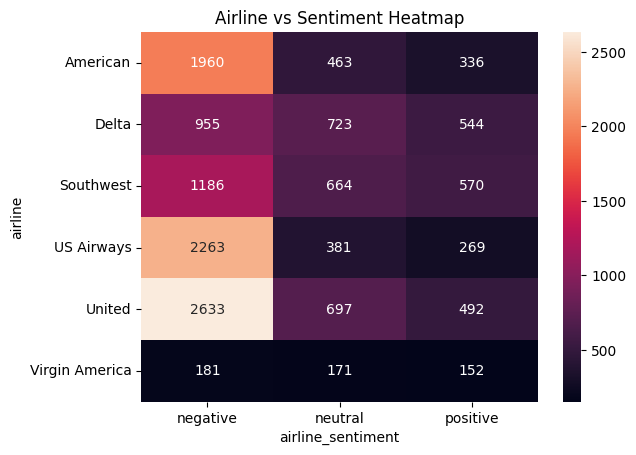

In [ ]:
pivot = pd.crosstab(tweets['airline'], tweets['airline_sentiment'])

sns.heatmap(pivot, annot=True, fmt='d')
plt.title("Airline vs Sentiment Heatmap")
plt.show()

## EXP 10: Poster Design for Business Product

Poster design is a visual communication method used to promote a product or service. It combines text, images, and design elements to attract attention and convey information effectively.

### Features
- Visually appealing layout
- Use of colors, fonts, and images
- Clear product message
- Branding elements (logo, tagline)

### Steps
1. Select a product to promote
2. Define target audience
3. Add product name and description
4. Include images and design elements
5. Add price, offer, or tagline
6. Finalize and export poster

The poster was successfully designed to promote the product with clear and attractive visual content.

## EXP 11: Poster Design for Business Product (Regional Language)

Regional poster design involves creating promotional content in a local language to target a specific audience. It improves communication and engagement with regional customers.

### Features
- Use of regional language (Hindi, Marathi, etc.)
- Cultural relevance
- Localized content
- Better audience connection

### Steps
1. Select product and target region
2. Translate content into regional language
3. Design layout with images and text
4. Use appropriate fonts for regional script
5. Add pricing and offers
6. Export final poster

The poster was successfully designed in regional language to effectively target local audience.

## EXP 12: Network Visualization using Gephi

Gephi is an open-source tool used for network analysis and visualization. It helps in representing relationships between entities such as users, nodes, and connections in a graphical format.

### Features
- Interactive graph visualization
- Supports large networks
- Various layout algorithms
- Community detection and analysis

### Steps
1. Import dataset (nodes and edges)
2. Generate network graph
3. Apply layout algorithms
4. Adjust node size and color
5. Analyze connections and patterns
6. Export visualization

The network was successfully visualized to analyze relationships between different entities.

## EXP 13: Network Visualization using NodeXL

NodeXL is a tool used for network analysis within Microsoft Excel. It allows users to visualize and analyze relationships between nodes such as users in a social network.

### Features
- Integration with Excel
- Easy network visualization
- Graph metrics and analysis
- Supports social media data

### Steps
1. Import data into NodeXL
2. Define nodes and edges
3. Generate network graph
4. Apply layout and formatting
5. Analyze graph metrics
6. Visualize relationships

The network visualization was successfully created using NodeXL to understand connections and patterns.

## EXP 14: Sentiment Cloud using Social Media Dataset

### Aim
To generate sentiment word clouds from social media data using Python.

### Theory
A word cloud is a visualization technique used to represent text data where the size of each word indicates its frequency or importance. In social media analytics, sentiment clouds help in identifying commonly used words in positive, negative, and neutral sentiments.

### Features
- Visual representation of text data
- Highlights frequently used words
- Easy identification of trends
- Supports sentiment-wise analysis

### Steps
1. Load and clean dataset
2. Separate data based on sentiment
3. Combine text for each sentiment
4. Generate word cloud using WordCloud library
5. Display visualization

The sentiment clouds were successfully generated to highlight frequently used words in social media data.

In [109]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)     # remove URLs
    text = re.sub(r"@\w+", "", text)        # remove mentions
    text = re.sub(r"#\w+", "", text)        # remove hashtags
    text = re.sub(r"[^A-Za-z\s]", "", text) # remove special chars
    return text.lower()

tweets['clean_text'] = tweets['text'].apply(clean_text)

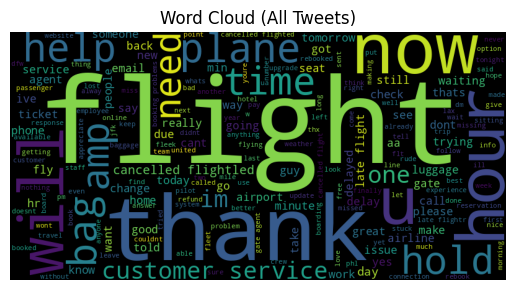

In [110]:
from wordcloud import WordCloud

text = " ".join(tweets['clean_text'].dropna())

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud (All Tweets)")
plt.show()

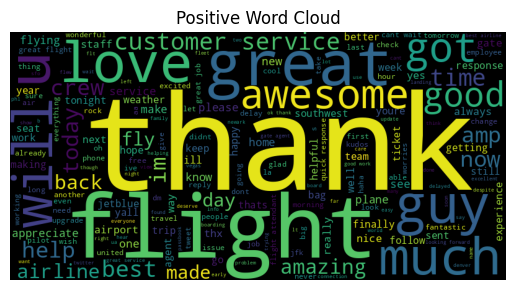

In [111]:
positive = tweets[tweets['airline_sentiment'] == 'positive']

text = " ".join(positive['clean_text'].dropna())

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Positive Word Cloud")
plt.show()

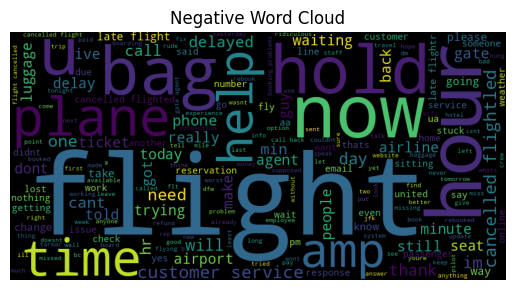

In [115]:
negative = tweets[tweets['airline_sentiment'] == 'negative']

text = " ".join(negative['clean_text'].dropna())

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Negative Word Cloud")
plt.show()

## EXP 15: Sentiment Cloud using Social Media Dataset (Regional)

### Aim
To generate sentiment word clouds from multilingual (regional) social media data using Python.

### Theory
A sentiment cloud is a visual representation of frequently used words in text data. In multilingual datasets, it helps in identifying important words across different languages such as Hindi, English, and other regional languages.

Cleaning and preprocessing are important to preserve language-specific characters while removing noise. Word clouds help in understanding common themes and user opinions in different languages.

### Features
- Supports multilingual text visualization
- Highlights frequent words across languages
- Easy identification of trends
- Useful for sentiment analysis

### Steps
1. Load and clean multilingual dataset
2. Separate data based on sentiment
3. Combine cleaned text
4. Generate word cloud
5. Display visualization

The multilingual sentiment cloud was successfully generated to visualize important words from regional data.

In [132]:
from datasets import load_dataset
dataset = load_dataset("dhruv0808/indic_sentiment_analyzer")
df = dataset['train'].to_pandas()

In [134]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_multilingual(text):
    text = str(text)
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)

    text = text.lower()
    
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

df['clean_text'] = df['Sentence'].apply(clean_multilingual)

[nltk_data] Downloading package stopwords to C:\Users\Soham
[nltk_data]     Mandavkar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


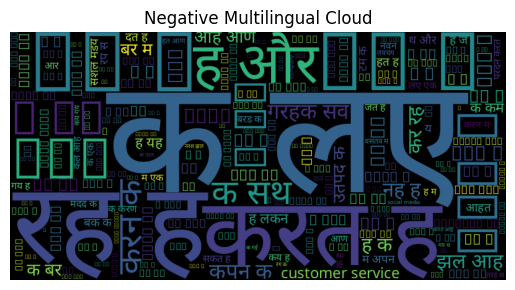

In [155]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'].dropna())

wc = WordCloud(
    font_path="C:/Projects/SEM 8 VIVA/SMA/NotoSans-Regular.ttf",
    width=800,
    height=400
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Negative Multilingual Cloud")
plt.show()

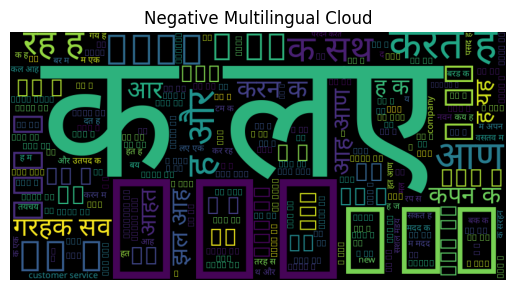

In [156]:
pos = df[df['Label'] == 'Positive']

text = " ".join(pos['clean_text'].dropna())

wc = WordCloud(
    font_path="C:/Projects/SEM 8 VIVA/SMA/NotoSans-Regular.ttf",
    width=800,
    height=400
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Negative Multilingual Cloud")
plt.show()

In [149]:
import os
print(os.getcwd())

c:\Projects\Sem 8 Viva


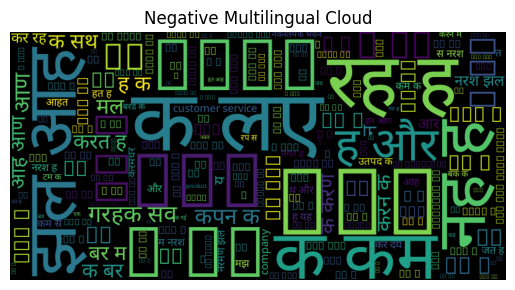

In [154]:
neg = df[df['Label'] == 'Negative']

text = " ".join(neg['clean_text'].dropna())

wc = WordCloud(
    font_path="C:/Projects/SEM 8 VIVA/SMA/NotoSans-Regular.ttf",
    width=800,
    height=400
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Negative Multilingual Cloud")
plt.show()

## EXP 16: Real-Time Dashboard using Looker Studio

Looker Studio is a data visualization and reporting tool by Google used to create real-time interactive dashboards. It connects with various data sources and provides live updates for better decision-making.

### Features
- Real-time data updates
- Interactive dashboards
- Integration with Google services
- Easy sharing and collaboration

### Steps
1. Open Looker Studio and create a report
2. Connect to a data source (sample dataset)
3. Add charts and visual elements
4. Apply filters and controls
5. Customize layout and design
6. Save and share dashboard

The real-time dashboard was successfully created to visualize live data and provide dynamic insights.

## EXP 17: Identify Keywords, Tags and Related Terms using Tool

Keyword analysis involves identifying important terms used in content to improve search visibility and understanding trends. Tools help extract keywords, tags, and related terms from text or websites.

### Features
- Identifies important keywords
- Suggests related terms
- Helps in SEO analysis
- Improves content optimization

### Steps
1. Open keyword analysis tool
2. Enter text or website URL
3. Extract keywords and tags
4. Analyze frequency and relevance
5. Identify related terms

Keywords, tags, and related terms were successfully identified to understand content trends and improve analysis.

## EXP 18: Identify Keywords, Tags and Related Terms using Tool

Keyword analysis involves identifying important terms used in content to improve search visibility and understanding trends. Tools help extract keywords, tags, and related terms from text or websites.

### Features
- Identifies important keywords
- Suggests related terms
- Helps in SEO analysis
- Improves content optimization

### Steps
1. Open keyword analysis tool
2. Enter text or website URL
3. Extract keywords and tags
4. Analyze frequency and relevance
5. Identify related terms

Keywords, tags, and related terms were successfully identified to understand content trends and improve analysis.